In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/ska_songs_clean.parquet")

ERA_ORDER = [
    "foundation",
    "expansion",
    "mainstream_peak",
    "post_peak",
    "revival",
    "modern"
]

print(f"Songs: {len(df)}")
print(f"Albums: {df["album"].nunique()}")

Songs: 1091
Albums: 83


In [12]:
### Convert Era to Ordered Categorical ###

df["era"] = pd.Categorical(
    df["era"],
    categories=ERA_ORDER,
    ordered=True
)

In [16]:
era_wc = df.groupby("era")["word_count"].agg(["count", "mean", "median"])
era_wc

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/3428977350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_wc = df.groupby("era")["word_count"].agg(["count", "mean", "median"])


,count,mean,median
era,,,
foundation,103,209.854369,204.0
expansion,278,249.928058,248.5
mainstream_peak,432,242.671296,227.0
post_peak,181,278.226519,243.0
revival,54,243.166667,242.5
modern,43,233.000000,224.0


/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2600035806.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era", sort=False)["word_count"].mean().plot(kind="bar")


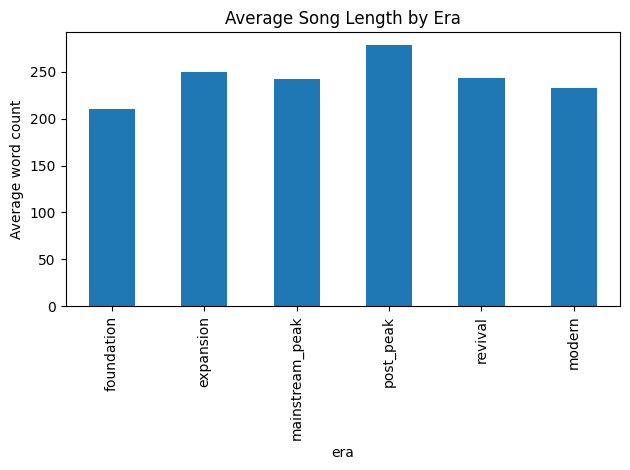

In [19]:
### Visualize the above findings ###

plt.figure()
df.groupby("era", sort=False)["word_count"].mean().plot(kind="bar")
plt.ylabel("Average word count")
plt.title("Average Song Length by Era")
plt.tight_layout()
plt.show()

In [20]:
### Lexical Diversity by Era ###
def lexical_diversity(text):
    words = text.split()
    if not words:
        return 0
    return len(set(words)) / len(words)

df["lex_div"] = df["lyrics_normalized"].apply(lexical_diversity)

In [21]:
era_ld = df.groupby("era")["lex_div"].agg(["mean", "median"])
era_ld

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/950141915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_ld = df.groupby("era")["lex_div"].agg(["mean", "median"])


,mean,median
era,,
foundation,0.464997,0.450980
expansion,0.404991,0.385016
mainstream_peak,0.424207,0.405945
post_peak,0.440099,0.423280
revival,0.418822,0.376009
modern,0.400764,0.400000


/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/411388666.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era", sort=False)["lex_div"].mean().plot(kind="bar")


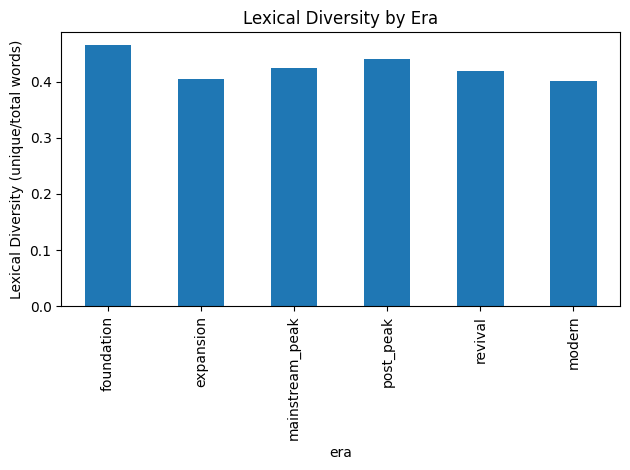

In [22]:
### Lexical Diversity Graph ###

plt.figure()
df.groupby("era", sort=False)["lex_div"].mean().plot(kind="bar")
plt.ylabel("Lexical Diversity (unique/total words)")
plt.title("Lexical Diversity by Era")
plt.tight_layout()
plt.show()

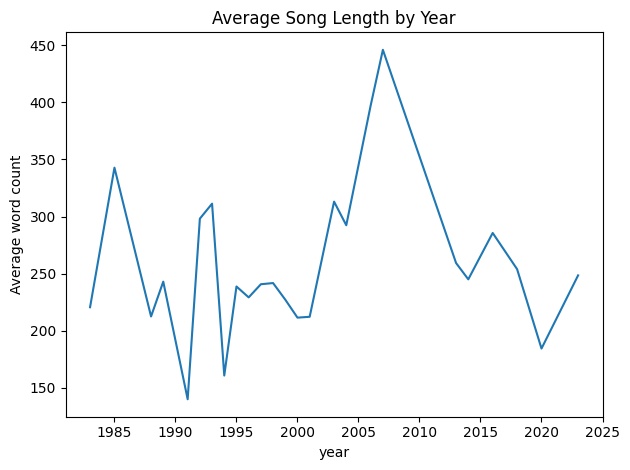

In [23]:
### Structural Trends Over Time ###
year_wc = df.groupby("year")["word_count"].mean()

plt.figure()
year_wc.plot()
plt.ylabel("Average word count")
plt.title("Average Song Length by Year")
plt.tight_layout()
plt.show()